<a href="https://colab.research.google.com/github/asternoeld/practical-ml-25-26/blob/main/assignment1/wine_quality_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [3]:
!pip install ucimlrepo

In [4]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
wine_quality = fetch_ucirepo(id=186)

# features (inputs)
X = wine_quality.data.features

# targets (output)
y = wine_quality.data.targets

print(X.head())
print(y.head())
print(X.shape)

   fixed_acidity  volatile_acidity  citric_acid  residual_sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free_sulfur_dioxide  total_sulfur_dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  
0      9.4  
1      9.8  
2      9.8  
3      9.8  
4      9.4  
   quali

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [9]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [10]:
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32).view(-1,1)

X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32).view(-1,1)

In [11]:
dataset = TensorDataset(X_train, y_train)

batch_size = 32

loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

In [12]:
# MODEL

model = nn.Sequential(
    nn.Linear(11, 64),
    nn.ReLU(),
    nn.Linear(64, 1)
)

In [13]:
loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [14]:
epochs = 100
losses = []

for epoch in range(epochs):

    epoch_loss = 0

    for xb, yb in loader:

        preds = model(xb)

        loss = loss_fn(preds, yb)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    epoch_loss /= len(loader)
    losses.append(epoch_loss)

    if epoch % 10 == 0:
        print("Epoch:", epoch, "Loss:", epoch_loss)

Epoch: 0 Loss: 18.581438376128308
Epoch: 10 Loss: 0.6319672498234942
Epoch: 20 Loss: 0.49132054824770593
Epoch: 30 Loss: 0.47020404927569664
Epoch: 40 Loss: 0.4610847231983407
Epoch: 50 Loss: 0.45390283147250216
Epoch: 60 Loss: 0.4475790924089818
Epoch: 70 Loss: 0.4438939135681632
Epoch: 80 Loss: 0.4383088575184711
Epoch: 90 Loss: 0.43674123396902725


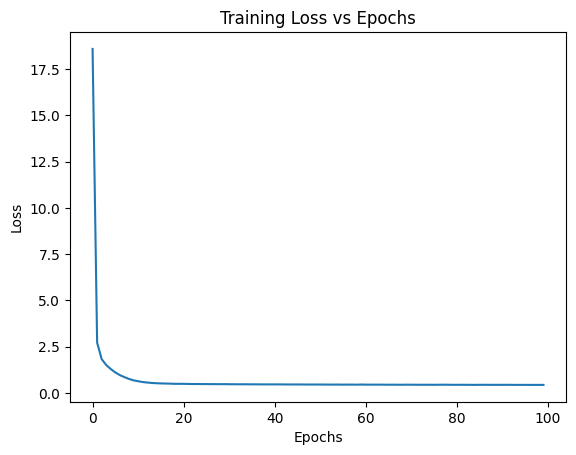

In [15]:
plt.plot(losses)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Loss vs Epochs")
plt.show()

In [16]:
# PREDICT

with torch.no_grad():
    y_pred = model(X_test).numpy()

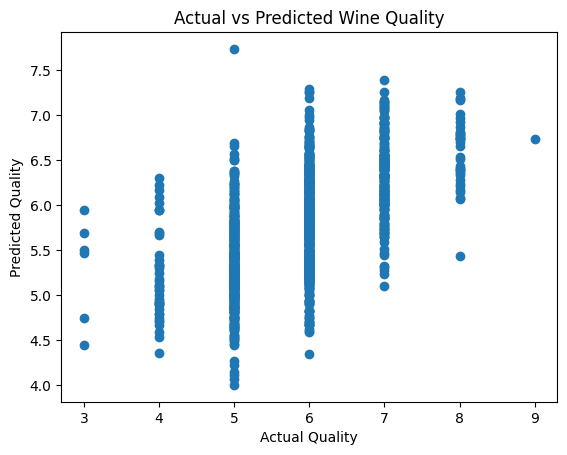

In [17]:
plt.scatter(y_test.numpy(), y_pred)
plt.xlabel("Actual Quality")
plt.ylabel("Predicted Quality")
plt.title("Actual vs Predicted Wine Quality")
plt.show()